In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Data directory
DATA_DIR = './hs300_data'

def prepare_data():
    # 1. Load benchmark index data
    df_index = pd.read_csv(os.path.join(DATA_DIR, '000300.SH.csv'))
    df_index['trade_date'] = df_index['trade_date'].astype(str)
    
    # Convert pct_chg to decimal returns
    mkt_ret = df_index.set_index('trade_date')['pct_chg'].sort_index() / 100.0
    
    # 2. Load 300 constituent stocks
    files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv') and f != '000300.SH.csv']
    all_stocks_ret = {}
    
    for f in files:
        code = f.replace('.csv', '')
        df = pd.read_csv(os.path.join(DATA_DIR, f))
        df['trade_date'] = df['trade_date'].astype(str)
        
        # Get returns and remove duplicate dates
        s_ret = df.drop_duplicates('trade_date').set_index('trade_date')['pct_chg'] / 100.0
        all_stocks_ret[code] = s_ret
        
    # Combine into a single DataFrame
    stocks_ret_df = pd.DataFrame(all_stocks_ret).sort_index()
    
    # 3. Align dates
    common_index = mkt_ret.index
    stocks_ret_df = stocks_ret_df.reindex(common_index).fillna(0)
    mkt_ret = mkt_ret.reindex(common_index).fillna(0)
    
    return mkt_ret, stocks_ret_df

mkt_ret, stocks_ret = prepare_data()

print(f"Data alignment completed. Time range: {mkt_ret.index[0]} to {mkt_ret.index[-1]}")
print(f"Total number of stocks: {stocks_ret.shape[1]}")

Data alignment completed. Time range: 20210311 to 20260409
Total number of stocks: 300


In [2]:
import pandas as pd
import numpy as np
import os

# Data directory
DATA_DIR = './hs300_data'

def prepare_data(rf_csv_path='shibor_rate_history.csv'):
    # 1. Load index data
    df_index = pd.read_csv(os.path.join(DATA_DIR, '000300.SH.csv'))
    df_index['trade_date'] = df_index['trade_date'].astype(str)
    
    # Convert percentage change to decimal returns
    mkt_ret_series = df_index.set_index('trade_date')['pct_chg'].sort_index() / 100.0
    
    # 2. Load constituent stock returns
    files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv') and f != '000300.SH.csv']
    all_stocks_ret = {}
    
    for f in files:
        code = f.replace('.csv', '')
        df = pd.read_csv(os.path.join(DATA_DIR, f))
        df['trade_date'] = df['trade_date'].astype(str)
        
        # Remove duplicate dates and compute returns
        all_stocks_ret[code] = (
            df.drop_duplicates('trade_date')
              .set_index('trade_date')['pct_chg'] / 100.0
        )
    
    # Combine all stocks into a single DataFrame
    stocks_ret_df = pd.DataFrame(all_stocks_ret).sort_index()
    
    # Align dates
    common_index = mkt_ret_series.index
    stocks_ret_df = stocks_ret_df.reindex(common_index).fillna(0)
    mkt_ret_series = mkt_ret_series.reindex(common_index).fillna(0)

    # 3. Subtract risk-free rate (if available)
    if os.path.exists(rf_csv_path):
        df_rf = pd.read_csv(rf_csv_path)
        
        # Convert date column to string for alignment
        df_rf['trade_date'] = df_rf['date'].astype(str)
        
        # Extract 1-year interest rate and convert to daily decimal rate
        rf_series = df_rf.set_index('trade_date')['1y'] / 100 / 252
        
        # Align risk-free rate to market dates (forward fill missing values)
        daily_rf = rf_series.reindex(common_index).ffill().fillna(0)
        
        # Compute excess returns (returns - risk-free rate)
        stocks_ret_df = stocks_ret_df.sub(daily_rf, axis=0)
        mkt_ret_series = mkt_ret_series - daily_rf

    return mkt_ret_series, stocks_ret_df

In [3]:
mkt_ret, stocks_ret = prepare_data()

In [4]:
def run_kf_cpu_vectorized(mkt_ret_series, stocks_ret_df):
    T, N = stocks_ret_df.shape
    
    # Market returns (T,)
    m = mkt_ret_series.values
    
    # Stock returns (T, N)
    s = stocks_ret_df.values
    
    # State vector: [beta, alpha], initialized as beta=1, alpha=0 for all stocks
    x = np.array([[1.0, 0.0]] * N).reshape(N, 2, 1)
    
    # Initial covariance matrix for each stock (2x2), replicated N times
    P = np.tile(np.eye(2), (N, 1, 1))
    
    # Process noise covariance
    Q = np.diag([1e-4, 1e-6])
    
    # Observation noise variance
    R = 0.01
    
    # Store beta estimates over time
    all_betas = np.zeros((T, N))
    
    print("Computing dynamic beta for each stock...")

    for t in range(T):
        # -------------------------
        # Prediction step
        # -------------------------
        P = P + Q
        
        # Observation matrix H for all stocks: shape (N, 1, 2)
        # Model: r_i,t = beta_i * m_t + alpha_i + noise
        H = np.zeros((N, 1, 2))
        H[:, 0, 0] = m[t]     # market return coefficient
        H[:, 0, 1] = 1.0      # alpha intercept
        
        # Transpose of H: (N, 2, 1)
        Ht = H.transpose(0, 2, 1)
        
        # Innovation covariance
        S = H @ P @ Ht + R
        
        # Kalman gain
        K = (P @ Ht) / S
        
        # Observation residual (prediction error)
        y = s[t].reshape(N, 1, 1) - (H @ x)
        
        # Update step
        x = x + K @ y
        P = (np.eye(2) - K @ H) @ P
        
        # Store beta estimates
        all_betas[t, :] = x[:, 0, 0]
    
    # Convert to DataFrame for convenience
    return pd.DataFrame(
        all_betas,
        index=stocks_ret_df.index,
        columns=stocks_ret_df.columns
    )


# Run Kalman filter estimation
beta_df = run_kf_cpu_vectorized(mkt_ret, stocks_ret)

print(f"Beta estimation completed, shape: {beta_df.shape}")

Computing dynamic beta for each stock...
Beta estimation completed, shape: (1231, 300)


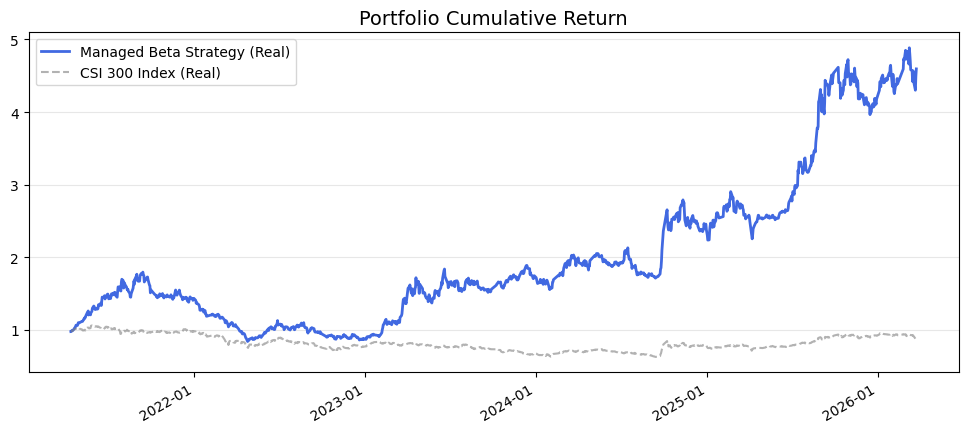


Performance Summary:
Annual Return:   37.74%
Sharpe Ratio:    0.99
Information Ratio:1.33
Max Drawdown:    -53.26%



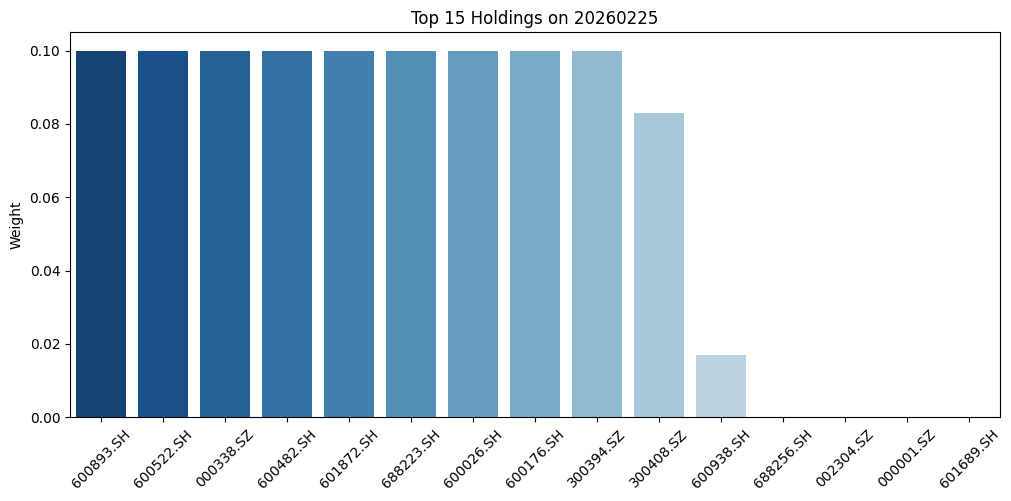

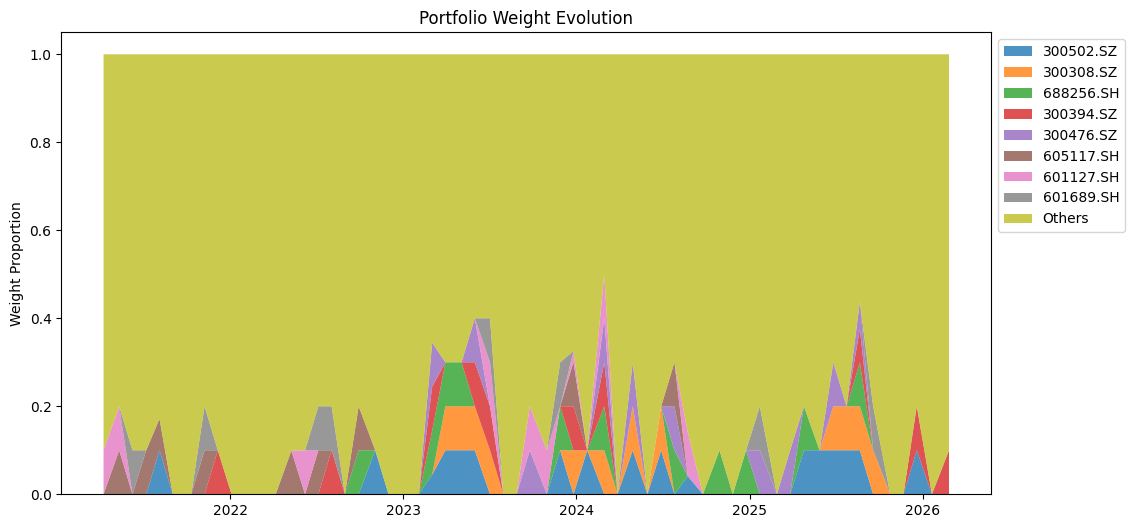

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import minimize
import os

# ---------------------------------------------------
# 1. Portfolio weight optimization (mean-alpha maximization)
# ---------------------------------------------------
def solve_weights_scipy(betas, alphas, target_beta=(0.95, 1.05), max_weight=0.1):
    # Convert inputs to numpy arrays
    b = betas.values.flatten().astype(np.float64)
    a = alphas.values.flatten().astype(np.float64)
    n = len(b)
    
    # Initial equal-weight portfolio
    w0 = np.ones(n) / n

    # Objective: maximize alpha -> minimize negative alpha
    def objective(w):
        return -(w @ a)

    # Constraints:
    constraints = [
        # Fully invested portfolio
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},
        
        # Beta lower bound
        {'type': 'ineq', 'fun': lambda w: (w @ b) - target_beta[0]},
        
        # Beta upper bound
        {'type': 'ineq', 'fun': lambda w: target_beta[1] - (w @ b)}
    ]

    # Long-only constraint with max position limit
    bounds = [(0, max_weight) for _ in range(n)]

    # Solve optimization problem
    res = minimize(
        objective,
        w0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        tol=1e-6
    )

    # Return solution or fallback to equal weight
    return res.x if res.success else w0


# ---------------------------------------------------
# 2. Risk-free rate preprocessing
# ---------------------------------------------------
rf_df = pd.read_csv('shibor_rate_history.csv')
rf_df['trade_date'] = rf_df['date'].astype(str)

# Convert annualized 1Y rate to daily risk-free rate
daily_rf_lookup = (
    rf_df.set_index('trade_date')['1y'] / 100 / 252
).reindex(stocks_ret.index).ffill().fillna(0)


# ---------------------------------------------------
# 3. Alpha factor definition
# ---------------------------------------------------
# 20-day cumulative return as a simple momentum-style alpha
alpha_df = stocks_ret.rolling(window=20).sum().fillna(0)


# ---------------------------------------------------
# 4. Backtesting loop (rebalancing every 20 days)
# ---------------------------------------------------
rebalance_days = list(range(20, len(mkt_ret), 20))

portfolio_rets = []
weights_history = []
rebalance_dates = []

for i in range(len(rebalance_days) - 1):
    curr_idx = rebalance_days[i]
    next_idx = rebalance_days[i + 1]
    curr_date = stocks_ret.index[curr_idx]

    # Current signals
    current_betas = beta_df.iloc[curr_idx]
    current_alphas = alpha_df.iloc[curr_idx]

    # Optimize portfolio weights
    weights = solve_weights_scipy(current_betas, current_alphas)
    
    # Store weights
    weights_history.append(weights)
    rebalance_dates.append(curr_date)

    # Compute out-of-sample returns until next rebalance
    period_excess_ret = stocks_ret.iloc[curr_idx + 1 : next_idx + 1]
    period_rf = daily_rf_lookup.iloc[curr_idx + 1 : next_idx + 1]

    # Portfolio return = active return + risk-free rate
    period_real_ret = (period_excess_ret @ weights) + period_rf
    portfolio_rets.append(period_real_ret)


# ---------------------------------------------------
# 5. Performance evaluation & equity curve
# ---------------------------------------------------
if portfolio_rets:
    strat_ret = pd.concat(portfolio_rets)

    benchmark_ret = (
        mkt_ret.loc[strat_ret.index] + daily_rf_lookup.loc[strat_ret.index]
    )

    strat_cum = (1 + strat_ret).cumprod()
    benchmark_cum = (1 + benchmark_ret).cumprod()

    # ---------------------------
    # Equity curve plot
    # ---------------------------
    plt.figure(figsize=(12, 5))
    ax = plt.gca()

    plot_index = pd.to_datetime(strat_cum.index)

    plt.plot(
        plot_index,
        strat_cum.values,
        label='Managed Beta Strategy (Real)',
        color='royalblue',
        lw=2
    )

    plt.plot(
        plot_index,
        benchmark_cum.values,
        label='CSI 300 Index (Real)',
        color='gray',
        alpha=0.6,
        ls='--'
    )

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    plt.gcf().autofmt_xdate(rotation=30)
    plt.title("Portfolio Cumulative Return", fontsize=14)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()


    # ---------------------------------------------------
    # 6. Performance metrics
    # ---------------------------------------------------
    total_days = len(strat_ret)

    ann_ret = (strat_cum.iloc[-1]) ** (252 / total_days) - 1
    ann_vol = strat_ret.std() * np.sqrt(252)

    sharpe = (
        ann_ret - (daily_rf_lookup.loc[strat_ret.index].mean() * 252)
    ) / ann_vol

    max_dd = (
        (strat_cum - strat_cum.cummax()) / strat_cum.cummax()
    ).min()

    info_ratio = (
        (strat_ret - benchmark_ret).mean()
        / (strat_ret - benchmark_ret).std()
    ) * np.sqrt(252)

    print(f"\nPerformance Summary:\n{'='*35}")
    print(f"Annual Return:   {ann_ret:.2%}")
    print(f"Sharpe Ratio:    {sharpe:.2f}")
    print(f"Information Ratio:{info_ratio:.2f}")
    print(f"Max Drawdown:    {max_dd:.2%}")
    print(f"{'='*35}\n")


    # ---------------------------------------------------
    # 7. Weight analysis
    # ---------------------------------------------------
    w_df = pd.DataFrame(
        weights_history,
        index=pd.to_datetime(rebalance_dates),
        columns=stocks_ret.columns
    )

    # ---------------------------
    # Top holdings (latest rebalance)
    # ---------------------------
    plt.figure(figsize=(12, 5))
    latest_top = w_df.iloc[-1].sort_values(ascending=False).head(15)

    sns.barplot(
        x=latest_top.index,
        y=latest_top.values,
        palette='Blues_r'
    )

    plt.title(f"Top 15 Holdings on {rebalance_dates[-1]}")
    plt.ylabel("Weight")
    plt.xticks(rotation=45)
    plt.show()


    # ---------------------------
    # Portfolio evolution (top 8 + others)
    # ---------------------------
    top_8_tickers = w_df.mean().sort_values(ascending=False).head(8).index

    area_df = w_df[top_8_tickers].copy()
    area_df['Others'] = w_df.drop(columns=top_8_tickers).sum(axis=1)

    plt.figure(figsize=(12, 6))
    plt.stackplot(area_df.index, area_df.T, labels=area_df.columns, alpha=0.8)

    plt.title("Portfolio Weight Evolution")
    plt.ylabel("Weight Proportion")
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.show()